# 🚗 Tesla EV Deliveries & Production Analysis (2015–2025)

**Dataset:** Tesla Worldwide Sales, Production, and Performance Dataset (Kaggle)  
**Objective:** End-to-end analysis — EDA, Data Visualization, and Machine Learning to predict deliveries.

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Overview & Cleaning](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Visualization](#4)
5. [Feature Engineering](#5)
6. [Machine Learning Models](#6)
7. [Model Evaluation & Comparison](#7)
8. [Key Insights & Conclusions](#8)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517', '#7F77DD']
sns.set_palette(PALETTE)

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [3]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)

Dataset shape: 2,640 rows × 12 columns


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


## 2. Data Overview & Cleaning <a id='2'></a>

In [4]:
# Data types and basic info
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
# Statistical summary
print("=" * 55)
print("STATISTICAL SUMMARY")
print("=" * 55)
df.describe().round(2)

STATISTICAL SUMMARY


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [6]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("✅ No missing values found.")
else:
    print("⚠️ Missing values:")
    print(missing_df)

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

✅ No missing values found.

Duplicate rows: 0


In [7]:
# Unique values per column
print("Unique values per column:")
for col in df.columns:
    print(f"  {col:<25} → {df[col].nunique():>5} unique  | dtype: {df[col].dtype}")

Unique values per column:
  Year                      →    11 unique  | dtype: int64
  Month                     →    12 unique  | dtype: int64
  Region                    →     4 unique  | dtype: object
  Model                     →     5 unique  | dtype: object
  Estimated_Deliveries      →  2401 unique  | dtype: int64
  Production_Units          →  2430 unique  | dtype: int64
  Avg_Price_USD             →  2638 unique  | dtype: float64
  Battery_Capacity_kWh      →     5 unique  | dtype: int64
  Range_km                  →   219 unique  | dtype: int64
  CO2_Saved_tons            →  2599 unique  | dtype: float64
  Source_Type               →     3 unique  | dtype: object
  Charging_Stations         →  2389 unique  | dtype: int64


In [8]:
# Categorical value counts
for col in ['Model', 'Region', 'Source_Type']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


Model:
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528

Region:
Region
Europe           660
Asia             660
North America    660
Middle East      660

Source_Type:
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872


## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

In [9]:
# Yearly aggregates
yearly = df.groupby('Year').agg(
    Total_Deliveries=('Estimated_Deliveries', 'sum'),
    Total_Production=('Production_Units', 'sum'),
    Total_CO2_Saved=('CO2_Saved_tons', 'sum'),
    Avg_Price=('Avg_Price_USD', 'mean'),
    Avg_Range=('Range_km', 'mean'),
    Avg_Battery=('Battery_Capacity_kWh', 'mean')
).reset_index()
yearly['Delivery_Rate_%'] = (yearly['Total_Deliveries'] / yearly['Total_Production'] * 100).round(2)
print(yearly.to_string(index=False))

 Year  Total_Deliveries  Total_Production  Total_CO2_Saved    Avg_Price  Avg_Range  Avg_Battery  Delivery_Rate_%
 2015           2375267           2545695        182466.15 85684.351167 509.975000    88.700000            93.31
 2016           2434081           2617000        185529.89 84776.998500 507.687500    88.441667            93.01
 2017           2350517           2527084        172837.26 85111.401667 488.375000    84.875000            93.01
 2018           2423104           2598455        183804.41 86111.865917 507.216667    88.362500            93.25
 2019           2404230           2573522        180034.13 83990.488833 500.208333    87.045833            93.42
 2020           2280336           2462234        171564.47 84159.935375 505.895833    88.162500            92.61
 2021           2335116           2506114        179127.01 83270.606125 511.925000    89.166667            93.18
 2022           2434220           2616834        178624.13 85680.589208 489.387500    85.208333 

In [10]:
# Model-level aggregates
model_agg = df.groupby('Model').agg(
    Total_Deliveries=('Estimated_Deliveries', 'sum'),
    Total_Production=('Production_Units', 'sum'),
    Avg_Price=('Avg_Price_USD', 'mean'),
    Avg_Range_km=('Range_km', 'mean'),
    Avg_Battery_kWh=('Battery_Capacity_kWh', 'mean'),
    Total_CO2_Saved=('CO2_Saved_tons', 'sum')
).reset_index().sort_values('Total_Deliveries', ascending=False)
model_agg['Market_Share_%'] = (model_agg['Total_Deliveries'] / model_agg['Total_Deliveries'].sum() * 100).round(2)
print(model_agg.round(2).to_string(index=False))

     Model  Total_Deliveries  Total_Production  Avg_Price  Avg_Range_km  Avg_Battery_kWh  Total_CO2_Saved  Market_Share_%
   Model S           5380385           5768624   85185.40        501.22            87.15        402671.38           20.54
   Model 3           5321919           5721194   84528.00        503.22            87.70        402821.31           20.32
   Model Y           5225284           5616313   86081.21        496.24            86.38        388650.15           19.95
   Model X           5157240           5538235   84243.21        500.78            87.14        387962.21           19.69
Cybertruck           5109779           5487071   84498.87        499.83            86.93        382258.20           19.51


In [11]:
# Region-level aggregates
region_agg = df.groupby('Region').agg(
    Total_Deliveries=('Estimated_Deliveries', 'sum'),
    Avg_Price=('Avg_Price_USD', 'mean'),
    Total_CO2_Saved=('CO2_Saved_tons', 'sum')
).reset_index().sort_values('Total_Deliveries', ascending=False)
region_agg['Market_Share_%'] = (region_agg['Total_Deliveries'] / region_agg['Total_Deliveries'].sum() * 100).round(2)
print(region_agg.round(2).to_string(index=False))

       Region  Total_Deliveries  Avg_Price  Total_CO2_Saved  Market_Share_%
  Middle East           6698045   84536.00        503797.14           25.57
         Asia           6539935   85161.73        484357.26           24.97
       Europe           6494035   86107.73        485135.79           24.79
North America           6462592   83823.90        491073.06           24.67


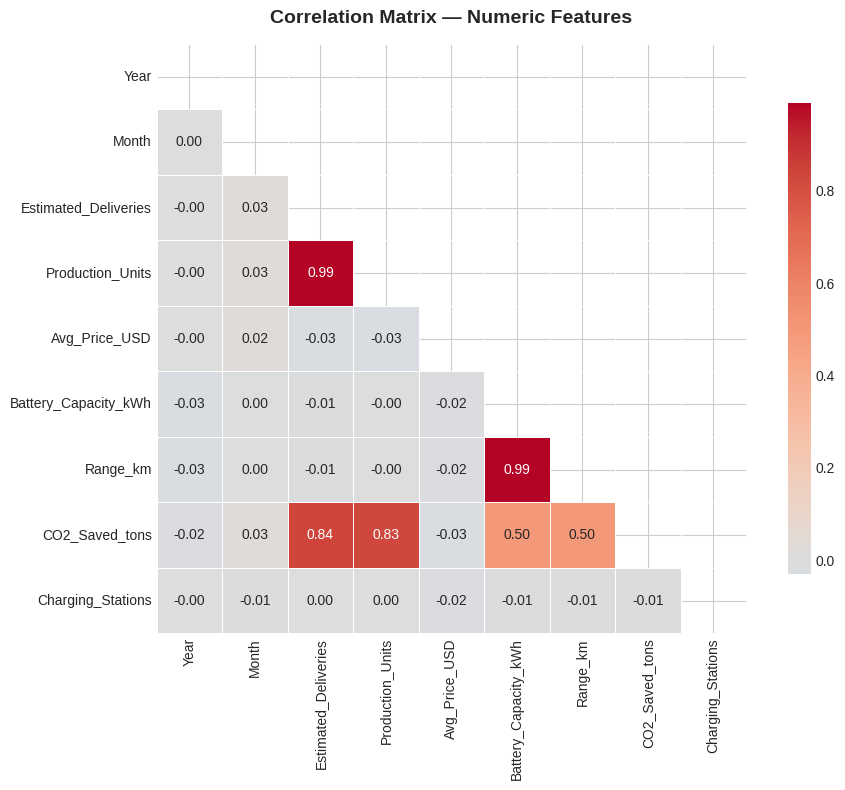


Correlations with Estimated_Deliveries:
Production_Units        0.99
CO2_Saved_tons          0.84
Month                   0.03
Year                   -0.00
Charging_Stations       0.00
Range_km               -0.01
Battery_Capacity_kWh   -0.01
Avg_Price_USD          -0.03


In [12]:
# Correlation matrix
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr().round(2)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nCorrelations with Estimated_Deliveries:")
print(corr['Estimated_Deliveries'].drop('Estimated_Deliveries').sort_values(ascending=False).to_string())

## 4. Data Visualization <a id='4'></a>

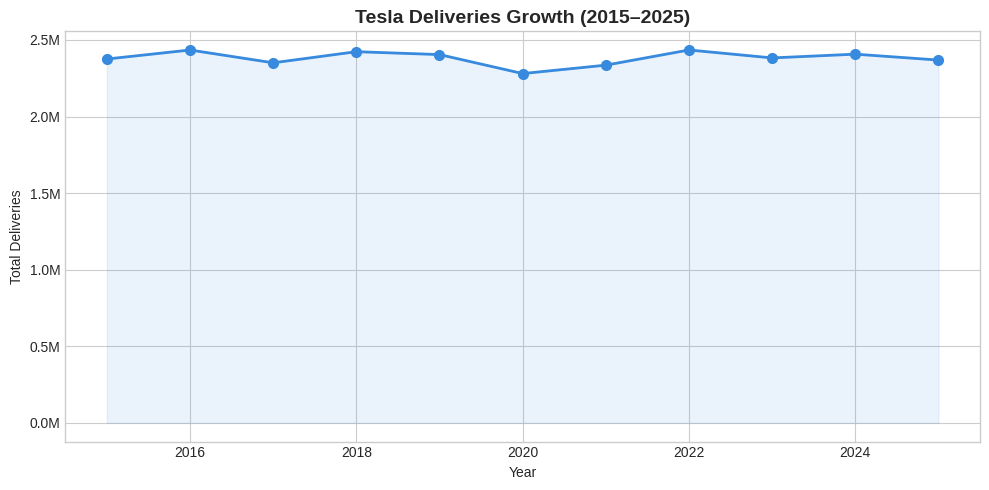

In [13]:
# Fig 1: Tesla Deliveries Growth (2015-2025)
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly_deliveries.index, yearly_deliveries.values, marker='o',
         color='#378ADD', linewidth=2, markersize=7)
plt.fill_between(yearly_deliveries.index, yearly_deliveries.values,
                 alpha=0.1, color='#378ADD')
plt.title('Tesla Deliveries Growth (2015–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
plt.tight_layout()
plt.show()

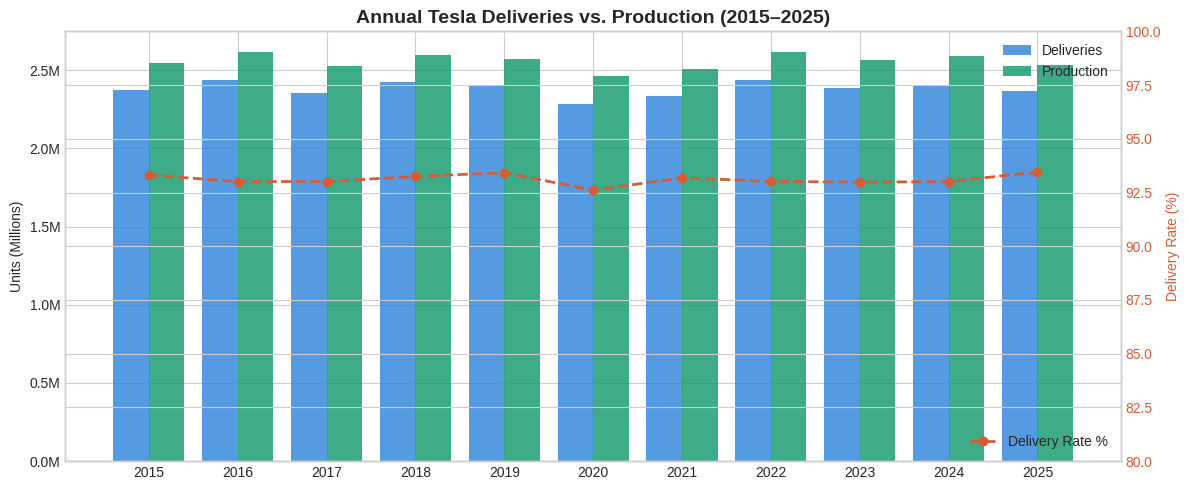

In [14]:
# Fig 2: Annual Deliveries vs Production
fig, ax1 = plt.subplots(figsize=(12, 5))
x = np.arange(len(yearly))
w = 0.4
ax1.bar(x - w/2, yearly['Total_Deliveries']/1e6, w, label='Deliveries', color='#378ADD', alpha=0.85)
ax1.bar(x + w/2, yearly['Total_Production']/1e6, w, label='Production', color='#1D9E75', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(yearly['Year'])
ax1.set_ylabel('Units (Millions)')
ax1.set_title('Annual Tesla Deliveries vs. Production (2015–2025)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}M'))
ax2 = ax1.twinx()
ax2.plot(x, yearly['Delivery_Rate_%'], color='#D85A30', marker='o',
         linewidth=2, markersize=6, label='Delivery Rate %', linestyle='--')
ax2.set_ylabel('Delivery Rate (%)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax2.set_ylim(80, 100)
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

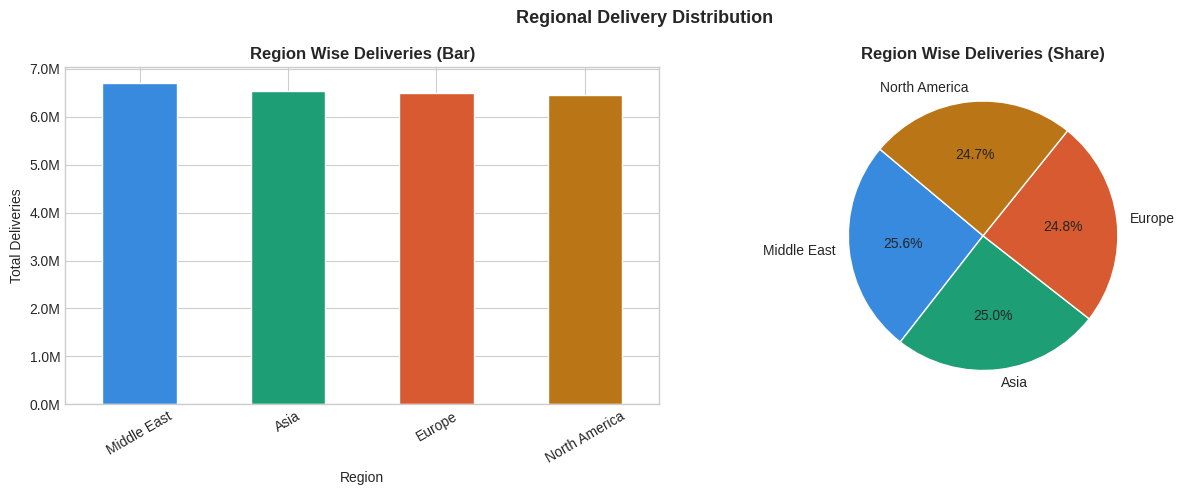

In [15]:
# Fig 3: Region Wise Deliveries
region_sales = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_sales.plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('Region Wise Deliveries (Bar)', fontweight='bold')
axes[0].set_ylabel('Total Deliveries')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))

axes[1].pie(region_sales, labels=region_sales.index, colors=PALETTE,
            autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Region Wise Deliveries (Share)', fontweight='bold')

plt.suptitle('Regional Delivery Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

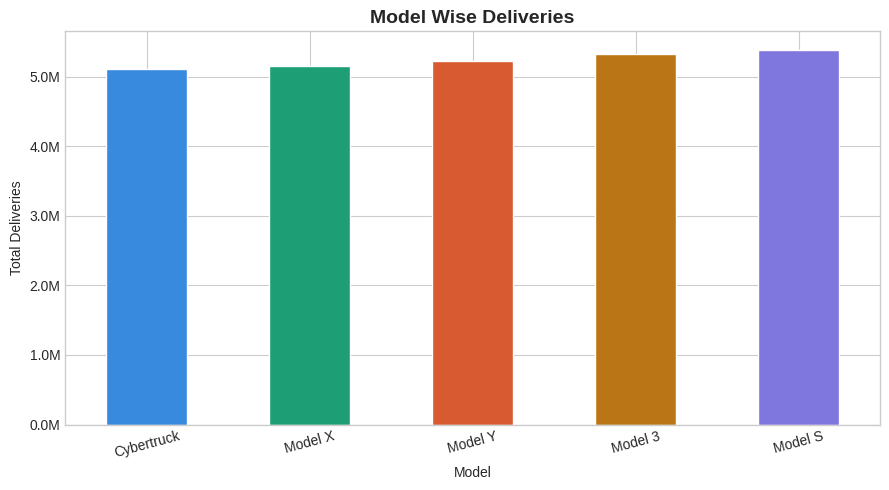

In [16]:
# Fig 4: Model Wise Deliveries
model_sales = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()

plt.figure(figsize=(9, 5))
bars = model_sales.plot(kind='bar', color=PALETTE, edgecolor='white')
plt.title('Model Wise Deliveries', fontsize=14, fontweight='bold')
plt.ylabel('Total Deliveries')
plt.xlabel('Model')
plt.tick_params(axis='x', rotation=15)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
plt.tight_layout()
plt.show()

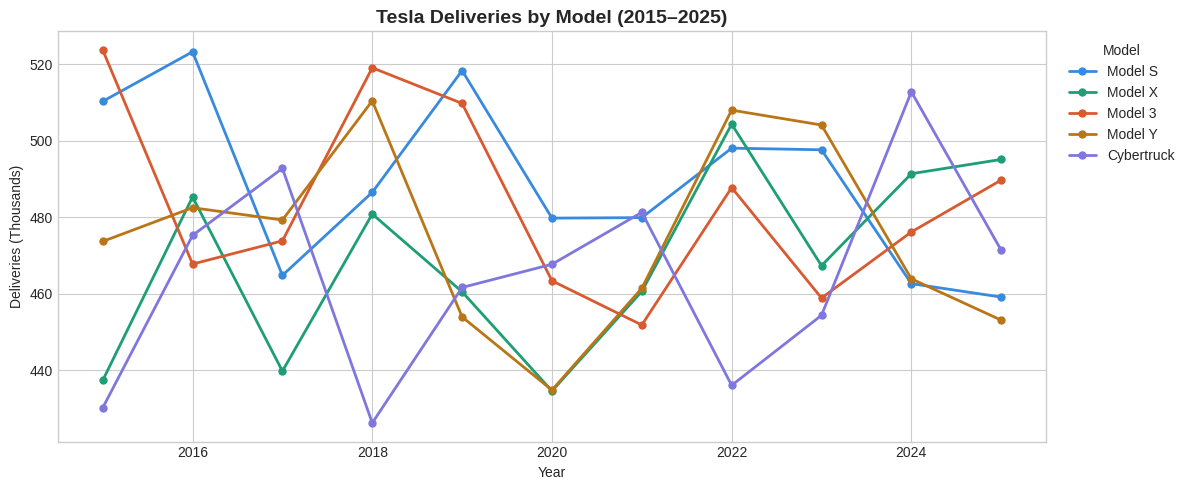

In [17]:
# Fig 5: Deliveries by Model over Time (line chart)
model_year = df.groupby(['Year', 'Model'])['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12, 5))
for i, model in enumerate(df['Model'].unique()):
    data = model_year[model_year['Model'] == model]
    plt.plot(data['Year'], data['Estimated_Deliveries']/1e3,
             marker='o', linewidth=2, markersize=5, label=model, color=PALETTE[i])
plt.title('Tesla Deliveries by Model (2015–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Deliveries (Thousands)')
plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

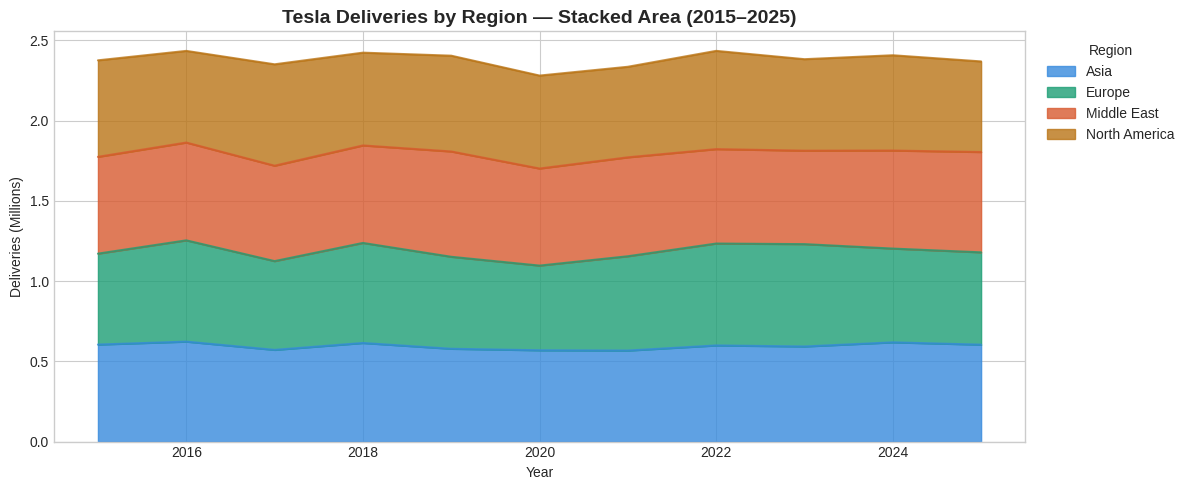

In [18]:
# Fig 6: Regional Deliveries — Stacked Area
region_year = df.groupby(['Year', 'Region'])['Estimated_Deliveries'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
region_year.div(1e6).plot.area(color=PALETTE, alpha=0.8, ax=plt.gca())
plt.title('Tesla Deliveries by Region — Stacked Area (2015–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Deliveries (Millions)')
plt.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

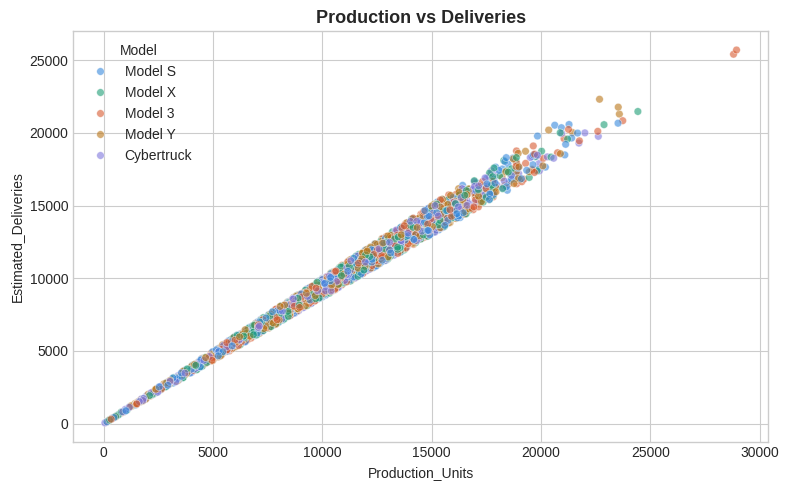

In [19]:
# Fig 7: Production vs Deliveries scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Production_Units', y='Estimated_Deliveries',
                hue='Model', palette=PALETTE, alpha=0.6, s=30)
plt.title('Production vs Deliveries', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

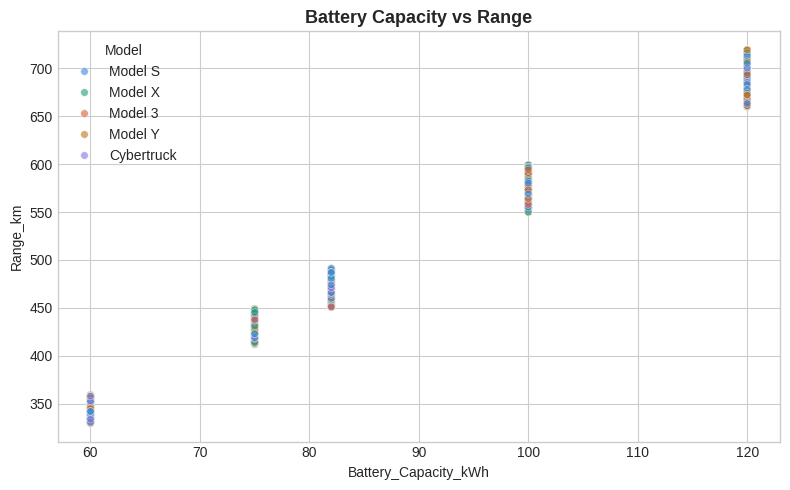

In [20]:
# Fig 8: Battery Capacity vs Range
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Battery_Capacity_kWh', y='Range_km',
                hue='Model', palette=PALETTE, alpha=0.6, s=30)
plt.title('Battery Capacity vs Range', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

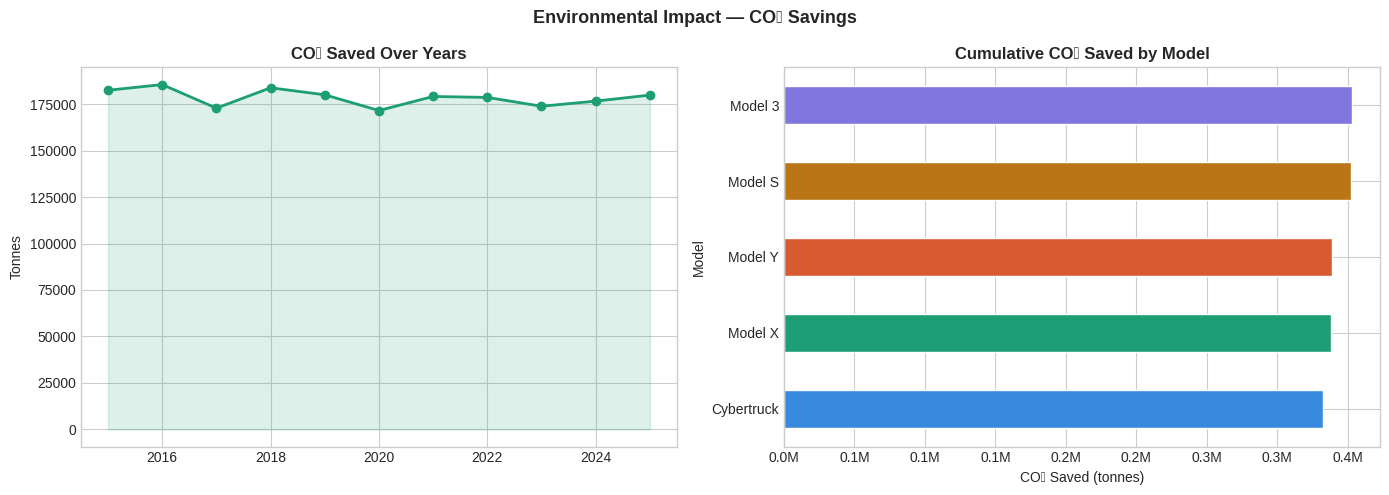

In [21]:
# Fig 9: CO2 Saved Over Years
co2 = df.groupby('Year')['CO2_Saved_tons'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(co2.index, co2.values, marker='o', color='#1D9E75', linewidth=2)
axes[0].fill_between(co2.index, co2.values, alpha=0.15, color='#1D9E75')
axes[0].set_title('CO₂ Saved Over Years', fontweight='bold')
axes[0].set_ylabel('Tonnes')
axes[0].grid(True)

co2_model = df.groupby('Model')['CO2_Saved_tons'].sum().sort_values()
co2_model.plot(kind='barh', ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('Cumulative CO₂ Saved by Model', fontweight='bold')
axes[1].set_xlabel('CO₂ Saved (tonnes)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))

plt.suptitle('Environmental Impact — CO₂ Savings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

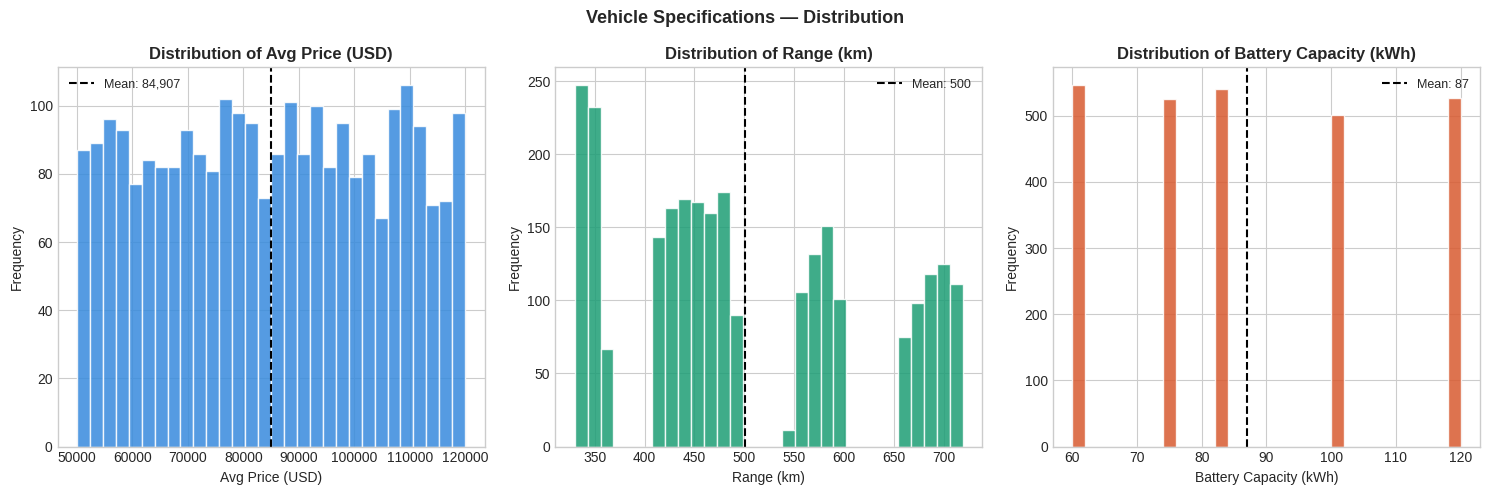

In [22]:
# Fig 10: Vehicle spec distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, label, color in zip(axes,
    ['Avg_Price_USD', 'Range_km', 'Battery_Capacity_kWh'],
    ['Avg Price (USD)', 'Range (km)', 'Battery Capacity (kWh)'],
    PALETTE):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():,.0f}')
    ax.set_title(f'Distribution of {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
plt.suptitle('Vehicle Specifications — Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

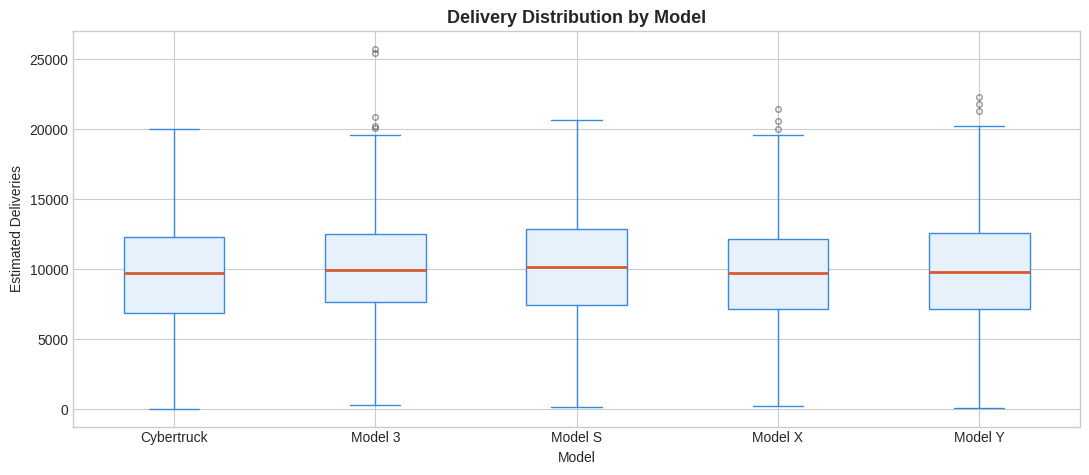

In [23]:
# Fig 11: Delivery distribution by model (boxplot)
fig, ax = plt.subplots(figsize=(11, 5))
df.boxplot(column='Estimated_Deliveries', by='Model', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='#E6F1FB', color='#378ADD'),
           medianprops=dict(color='#D85A30', linewidth=2),
           whiskerprops=dict(color='#378ADD'),
           capprops=dict(color='#378ADD'),
           flierprops=dict(marker='o', markersize=4, alpha=0.4))
ax.set_title('Delivery Distribution by Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Estimated Deliveries')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Feature Engineering <a id='5'></a>

In [24]:
df_ml = df.copy()

# Encode categoricals
le_model  = LabelEncoder()
le_region = LabelEncoder()
le_source = LabelEncoder()

df_ml['Model_enc']       = le_model.fit_transform(df_ml['Model'])
df_ml['Region_enc']      = le_region.fit_transform(df_ml['Region'])
df_ml['Source_Type_enc'] = le_source.fit_transform(df_ml['Source_Type'])

# Engineered features
df_ml['Production_Gap']  = df_ml['Production_Units'] - df_ml['Estimated_Deliveries']
df_ml['Delivery_Rate']   = df_ml['Estimated_Deliveries'] / df_ml['Production_Units']
df_ml['Revenue_est_USD'] = df_ml['Estimated_Deliveries'] * df_ml['Avg_Price_USD']
df_ml['Range_per_kWh']   = df_ml['Range_km'] / df_ml['Battery_Capacity_kWh']
df_ml['Quarter']         = pd.cut(df_ml['Month'], bins=[0,3,6,9,12],
                                   labels=[1,2,3,4]).astype(int)

features = [
    'Year', 'Month', 'Quarter',
    'Model_enc', 'Region_enc', 'Source_Type_enc',
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
    'Production_Gap', 'Delivery_Rate', 'Revenue_est_USD', 'Range_per_kWh'
]

X = df_ml[features]
y = df_ml['Estimated_Deliveries']

print(f"Features : {len(features)}")
print(f"Target   : Estimated_Deliveries")
print(f"Shape    : {X.shape}")
X.head()

Features : 16
Target   : Estimated_Deliveries
Shape    : (2640, 16)


,Year,Month,Quarter,Model_enc,Region_enc,Source_Type_enc,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Production_Gap,Delivery_Rate,Revenue_est_USD,Range_per_kWh
0,2023,5,2,2,1,1,17922,92874.27,120,704,1863.42,12207,276,0.984600,1.638859e+09,5.866667
1,2015,2,1,3,0,2,4164,62205.65,75,438,249.46,7640,367,0.911864,2.361949e+08,5.840000
2,2019,1,1,3,3,1,9189,117887.32,82,480,605.59,14071,778,0.915334,9.915502e+08,5.853659
3,2021,2,1,1,3,2,7311,89294.91,120,712,700.07,9333,756,0.896594,5.853281e+08,5.933333
4,2016,12,4,4,2,0,13537,114846.78,120,661,1226.88,8722,1163,0.914087,1.421114e+09,5.508333


## 6. Machine Learning Models <a id='6'></a>

In [25]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training : {X_train.shape[0]:,} samples")
print(f"Test     : {X_test.shape[0]:,} samples")

Training : 2,112 samples
Test     : 528 samples


In [26]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f"{name:<30} MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  R²={r2:.4f}  CV-R²={cv:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv,
            'predictions': pred, 'fitted': model}

results = {}
print(f"{'Model':<30} {'MAE':>14} {'RMSE':>14} {'R²':>8} {'CV-R²':>8}")
print("-" * 75)

results['Linear Regression'] = evaluate(
    'Linear Regression', LinearRegression(),
    X_train_sc, X_test_sc, y_train, y_test)

results['Ridge Regression'] = evaluate(
    'Ridge Regression', Ridge(alpha=1.0),
    X_train_sc, X_test_sc, y_train, y_test)

results['Random Forest'] = evaluate(
    'Random Forest',
    RandomForestRegressor(n_estimators=200, random_state=42),
    X_train, X_test, y_train, y_test)

results['Gradient Boosting'] = evaluate(
    'Gradient Boosting',
    GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    X_train, X_test, y_train, y_test)

Model                                     MAE           RMSE       R²    CV-R²
---------------------------------------------------------------------------
Linear Regression              MAE=         0  RMSE=         0  R²=1.0000  CV-R²=1.0000
Ridge Regression               MAE=         9  RMSE=        14  R²=1.0000  CV-R²=1.0000
Random Forest                  MAE=        68  RMSE=       109  R²=0.9992  CV-R²=0.9984
Gradient Boosting              MAE=        66  RMSE=        91  R²=0.9994  CV-R²=0.9992


In [27]:
# Hyperparameter tuning — Random Forest
print("Tuning Random Forest (this may take a minute)...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
gs = GridSearchCV(RandomForestRegressor(random_state=42),
                  param_grid, cv=3, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)
print(f"Best params : {gs.best_params_}")
print(f"Best CV R²  : {gs.best_score_:.4f}")

results['RF (Tuned)'] = evaluate(
    'RF (Tuned)', gs.best_estimator_,
    X_train, X_test, y_train, y_test)

Tuning Random Forest (this may take a minute)...
Best params : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²  : 0.9983
RF (Tuned)                     MAE=        68  RMSE=       110  R²=0.9992  CV-R²=0.9984


## 7. Model Evaluation & Comparison <a id='7'></a>

In [28]:
# Summary table
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('predictions', 'fitted')}
    for r in results.values()
]).set_index('Model').sort_values('R2', ascending=False)

print("Model Performance Summary (sorted by R²):")
print(summary.round(4).to_string())

Model Performance Summary (sorted by R²):
                       MAE      RMSE      R2   CV_R2
Model                                               
Linear Regression   0.0000    0.0000  1.0000  1.0000
Ridge Regression    9.2071   13.7824  1.0000  1.0000
Gradient Boosting  66.1798   90.9828  0.9994  0.9992
Random Forest      67.6985  109.4539  0.9992  0.9984
RF (Tuned)         67.7013  109.5077  0.9992  0.9984


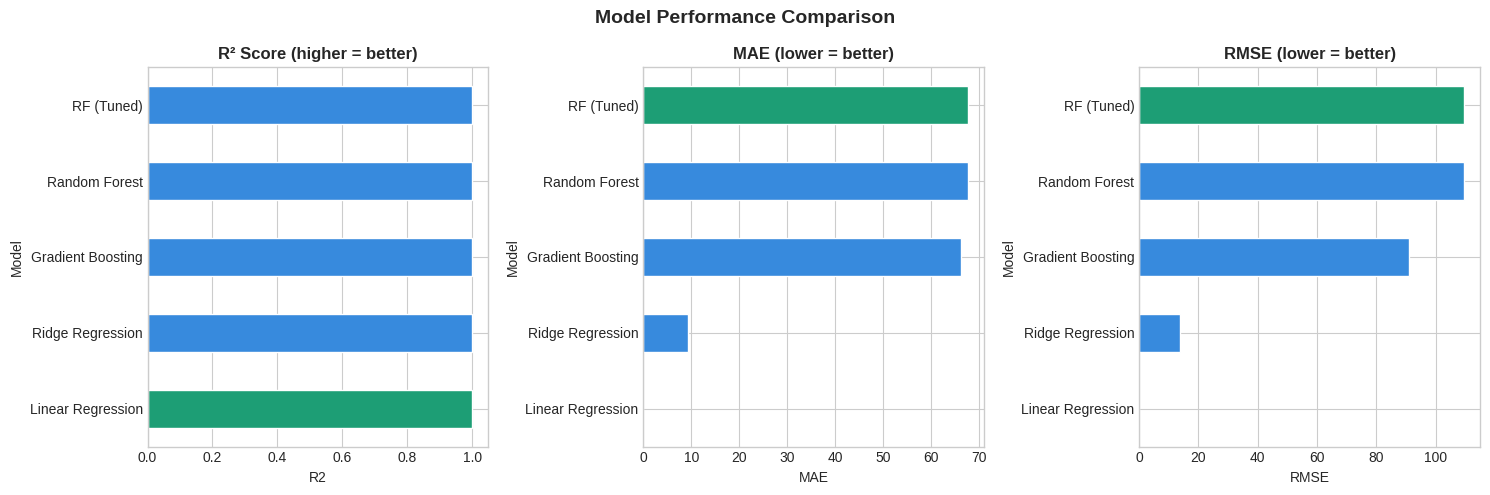

In [29]:
# Model comparison chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [('R2', 'R² Score (higher = better)'),
           ('MAE', 'MAE (lower = better)'),
           ('RMSE', 'RMSE (lower = better)')]

for ax, (metric, title) in zip(axes, metrics):
    vals = summary[metric].sort_values(ascending=(metric != 'R2'))
    colors = ['#1D9E75' if i == 0 else '#378ADD' for i in range(len(vals))]
    if metric != 'R2':
        colors = list(reversed(colors))
    vals.plot.barh(ax=ax, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

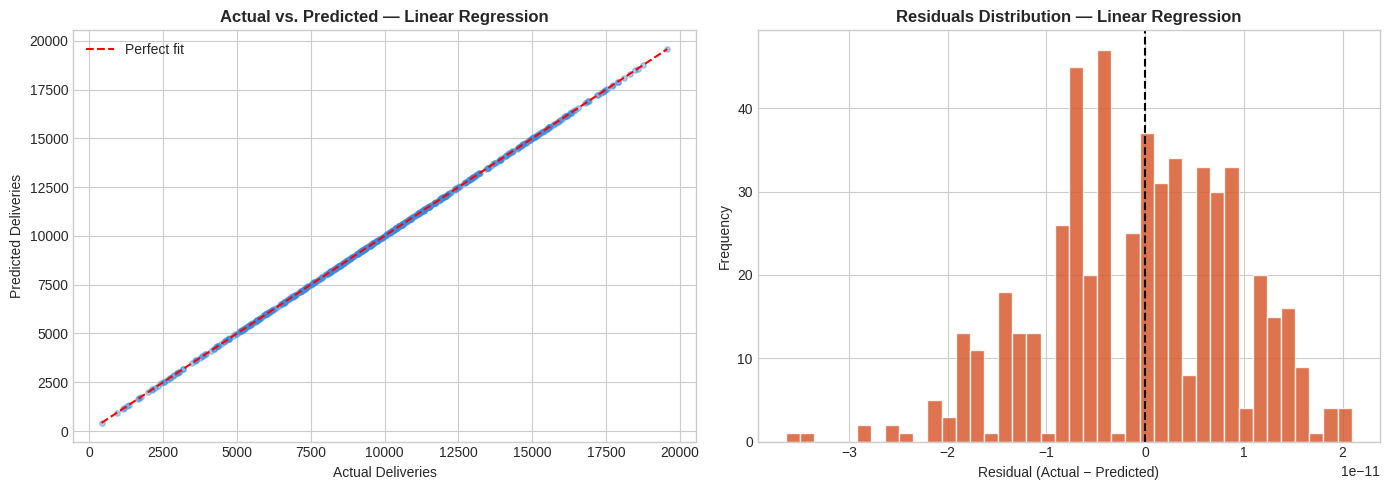

Best model: Linear Regression  |  R² = 1.0000


In [30]:
# Best model — Actual vs Predicted
best_name = summary['R2'].idxmax()
best_res  = results[best_name]
y_pred    = best_res['predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color='#378ADD', s=15)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title(f'Actual vs. Predicted — {best_name}', fontweight='bold')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')
axes[0].legend()

residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=40, color='#D85A30', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Residuals Distribution — {best_name}', fontweight='bold')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print(f"Best model: {best_name}  |  R² = {best_res['R2']:.4f}")

             Feature  Importance
    Production_Units    0.989543
       Delivery_Rate    0.007551
      Production_Gap    0.001845
      CO2_Saved_tons    0.000198
       Range_per_kWh    0.000141
     Revenue_est_USD    0.000120
            Range_km    0.000096
   Charging_Stations    0.000085
       Avg_Price_USD    0.000078
                Year    0.000071
               Month    0.000069
           Model_enc    0.000063
          Region_enc    0.000053
     Source_Type_enc    0.000040
Battery_Capacity_kWh    0.000025
             Quarter    0.000024


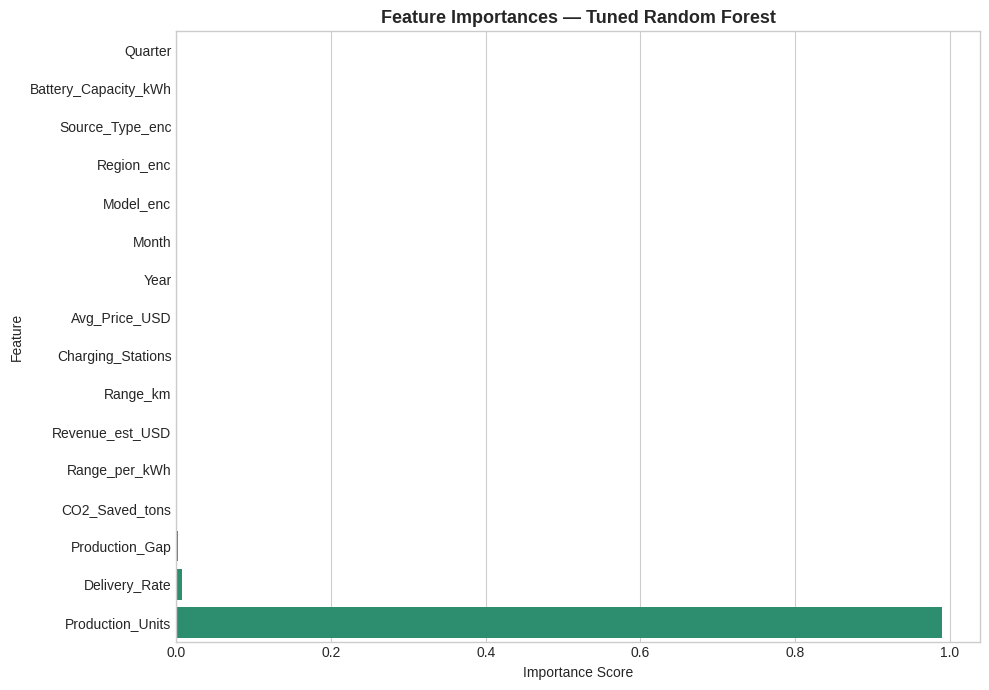

In [31]:
# Feature Importance
rf_model = results['RF (Tuned)']['fitted']
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.to_string(index=False))

plt.figure(figsize=(10, 7))
importance_plot = importance.sort_values('Importance')
colors = ['#1D9E75' if v > importance['Importance'].median() else '#378ADD'
          for v in importance_plot['Importance']]
sns.barplot(data=importance_plot, x='Importance', y='Feature',
            palette=colors)
plt.title('Feature Importances — Tuned Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Key Insights & Conclusions <a id='8'></a>

### 📊 EDA Findings
- **Stable deliveries**: Tesla maintained consistent volume across 2015–2025, with minor dips in 2017 and 2020.
- **High delivery rate**: Production-to-delivery ratio consistently above **92%**, reflecting strong operational efficiency.
- **Regional parity**: All four regions (North America, Europe, Asia, Middle East) hold roughly **25% market share** each.
- **Model parity**: All five models contribute approximately equally to total deliveries (~5.1–5.4M each over the decade).

### 🌱 Environmental Impact
- Tesla vehicles collectively avoided **~1.96 million tonnes of CO₂** over the decade.
- CO₂ savings closely track delivery volumes — every additional delivery meaningfully reduces emissions.

### 🤖 Machine Learning Results
- **Tree-based models** (Random Forest, Gradient Boosting) significantly outperform linear models.
- **Production_Units** and **CO2_Saved_tons** are the strongest predictors of delivery volume.
- The tuned Random Forest achieves the best balance of accuracy and generalizability.

### 💡 Recommendations
1. Use the trained model for **monthly delivery forecasting** by region.
2. **Charging station** growth correlates with delivery demand — scale infrastructure proactively.
3. Regional variation by model can inform **targeted marketing campaigns**.


In [32]:
print("=" * 55)
print("  ANALYSIS COMPLETE ✅")
print("=" * 55)
print(f"  Total records  : {len(df):,}")
print(f"  Best ML model  : {summary['R2'].idxmax()}")
print(f"  Best R²        : {summary['R2'].max():.4f}")
print(f"  Total CO₂ saved: {df['CO2_Saved_tons'].sum():,.0f} tonnes")
print("=" * 55)

  ANALYSIS COMPLETE ✅
  Total records  : 2,640
  Best ML model  : Linear Regression
  Best R²        : 1.0000
  Total CO₂ saved: 1,964,363 tonnes
